# Data Cleaning

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Raw" # folder containing the 5 CSV files

## 1. Baltic Dry Index

In [5]:
# Load Baltic Dry Index Dataset
bdi = pd.read_csv(f"{DATA_DIR}/01_baltic_dry_index_daily.csv", parse_dates=["Date"])

In [6]:
bdi.head()

,Date,BDI_Close,BDI_High,BDI_Low
0,2000-01-04,1320,1320,1320
1,2000-01-05,1329,1329,1329
2,2000-01-06,1351,1351,1351
3,2000-01-07,1368,1368,1368
4,2000-01-10,1376,1376,1376


In [7]:
bdi.tail()

,Date,BDI_Close,BDI_High,BDI_Low
5987,2023-12-18,2288,2288,2288
5988,2023-12-19,2219,2219,2219
5989,2023-12-20,2150,2150,2150
5990,2023-12-21,2087,2087,2087
5991,2023-12-22,2094,2094,2094


In [8]:
# Check dimensions of data
bdi.shape

(5992, 4)

In [9]:
# Check structure
bdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992 entries, 0 to 5991
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5992 non-null   datetime64[ns]
 1   BDI_Close  5992 non-null   int64         
 2   BDI_High   5992 non-null   int64         
 3   BDI_Low    5992 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 187.4 KB


No null values

In [10]:
# Check date range
print(f"Date range: {bdi['Date'].min().date()} to {bdi['Date'].max().date()}")

Date range: 2000-01-04 to 2023-12-22


In [11]:
# Check for duplicate rows
bdi.duplicated().sum()

np.int64(3)

In [12]:
# Drop duplicates
bdi = bdi.drop_duplicates()

In [13]:
# Check new dimensions
bdi.shape

(5989, 4)

In [14]:
# Check if dates are sorted
bdi['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [15]:
# Check for duplicate dates
bdi['Date'].duplicated().sum()

np.int64(0)

In [16]:
# Summary statistics
bdi.describe()

,Date,BDI_Close,BDI_High,BDI_Low
count,5989,5989.000000,5989.000000,5989.000000
mean,2011-12-25 03:39:45.773918720,2244.805978,2244.613959,2244.549507
min,2000-01-04 00:00:00,290.000000,0.000000,0.000000
25%,2005-12-22 00:00:00,1025.000000,1025.000000,1025.000000
50%,2011-12-20 00:00:00,1559.000000,1559.000000,1559.000000
75%,2017-12-15 00:00:00,2696.000000,2696.000000,2696.000000
max,2023-12-22 00:00:00,11793.000000,11793.000000,11793.000000
std,NaN,1931.535463,1931.728391,1931.725691


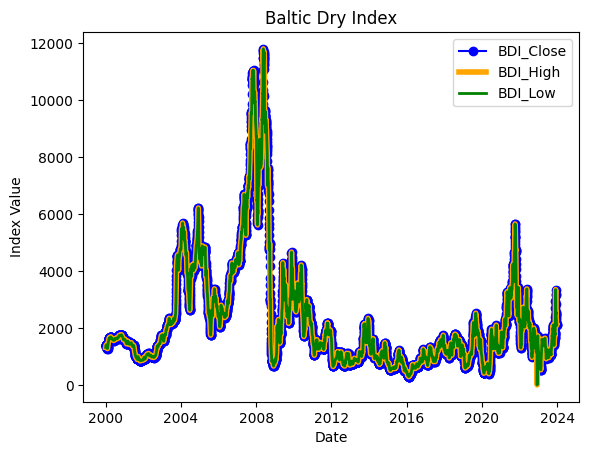

In [19]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(bdi['Date'], bdi['BDI_Close'], label='BDI_Close', color='blue', marker='o')
ax.plot(bdi['Date'], bdi['BDI_High'], label='BDI_High', color='orange', linewidth=4)
ax.plot(bdi['Date'], bdi['BDI_Low'], label='BDI_Low', color='green', linewidth=2)

ax.set_title('Baltic Dry Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.legend()  # Displays the labels assigned above

plt.show()

## 2. Brent Crude Oil Prices